In [1]:
# In this notebook, I  will calculate and plot Doppler shift as a function of satellite radial velocity
# The goal is to understand how satellite motion changes the received carrier frequency in a SatCom link

## Dopler Shift Theory 

The simplified Doppler Shift equation is:

\[
    f_D = -\frac{v_r}{c} f_c
\]

where:
- \(f_D\) is the Doppler shift in Hz
- \(v_r\) is radial velocity in m/s
- \(c\) is the speed of light in m/s
- \(f_c\) is the carrier frequency in Hz

Sign convention: 

- Negative radial velocity means the satellite is approaching the receiver (\(v_r\) < 0 -> satellite approaching -> positive Doppler shift)
- Positive radial velocity means the satellite is moving away from the receiver (\(v_r\) > 0 -> satellite moving away -> negative Doppler Shift) 


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Constant and Function 

SPEED_OF_LIGHT_M_PER_S = 299_792_458

def calculate_doppler_shift(radial_velocity_m_per_s, carrier_frequency_hz):
    """
    Calculate Doppler shift for a given radial velocity and carrier frequency.

    Parameters
    -----------
    radial_velocity_m_per_s: float or numpy array
        Radial velocity in m/s
        Negative means the satellite is approaching
        Positive means the satellite is moving away

    carrier_frequency_hz : float 
        Carrier frequency in Hz 

    Returns
    ----------
    float or numpy array
        Doppler shift in Hz 
    """
    doppler_shift_hz = -(radial_velocity_m_per_s / SPEED_OF_LIGHT_M_PER_S) * carrier_frequency_hz

    return doppler_shift_hz

In [8]:
# input data 
s_band_frequency_hz = 2.2e9   # 2.2 x 10^9 Hz = 2.2 GHz
x_band_frequency_hz = 8.4e9   # 8.4 x 10^9 Hz = 8.4 GHz

radial_velocities_m_per_s = np.linspace(-7500, 7500, 301)
radial_velocities_km_per_s = radial_velicities_m_per_s / 1000

In [9]:
s_band_doppler_hz = calculate_doppler_shift(radial_velocities_m_per_s, s_band_frequency_hz)
x_band_doppler_hz = calculate_doppler_shift(radial_velocities_m_per_s, x_band_frequency_hz)

s_band_doppler_kHz = s_band_doppler_hz / 1000
x_band_doppler_kHz = x_band_doppler_hz / 1000

In [11]:
# inspection of some values

print("Doppler Shift Examples")
print("----------------------")

print(f"S-band at -7.5 km/s: {s_band_doppler_kHz[0]:.2f} kHz")
print(f"S-band at 0.0 km/s: {s_band_doppler_kHz[150]:.2f} kHz")
print(f"S-band at 7.5 km/s: {s_band_doppler_kHz[-1]:.2f} kHz")

print()

print(f"X-band at -7.5 km/s: {x_band_doppler_kHz[0]:.2f} kHz")
print(f"X-band at -7.5 km/s: {x_band_doppler_kHz[150]:.2f} kHz")
print(f"X-band at -7.5 km/s: {x_band_doppler_kHz[-1]:.2f} kHz")

Doppler Shift Examples
----------------------
S-band at -7.5 km/s: 55.04 kHz
S-band at 0.0 km/s: -0.00 kHz
S-band at 7.5 km/s: -55.04 kHz

X-band at -7.5 km/s: 210.15 kHz
X-band at -7.5 km/s: -0.00 kHz
X-band at -7.5 km/s: -210.15 kHz


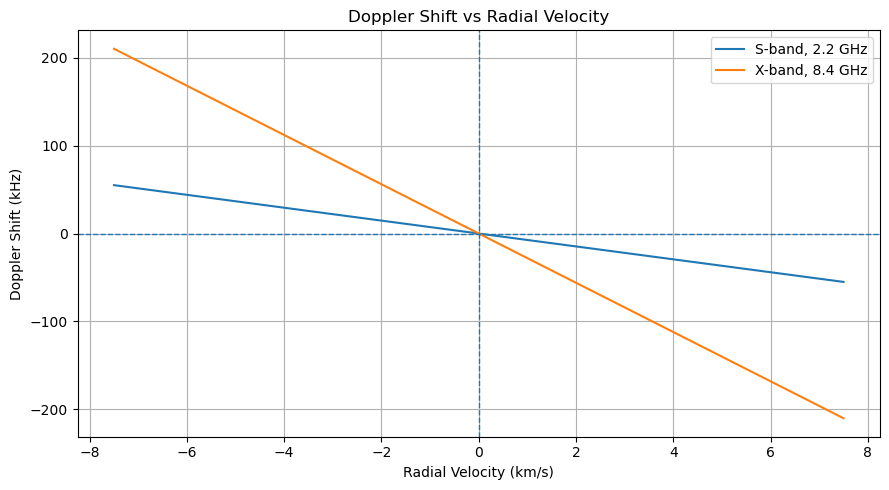

In [15]:
# plotting 

plt.figure(figsize=(9,5))

plt.plot(
    radial_velocities_km_per_s,
    s_band_doppler_kHz,
    label = "S-band, 2.2 GHz"
)

plt.plot(
    radial_velocities_km_per_s,
    x_band_doppler_kHz,
    label = "X-band, 8.4 GHz"
)

plt.axhline(0, linestyle="--", linewidth = 1)
plt.axvline(0, linestyle="--", linewidth = 1)

plt.title("Doppler Shift vs Radial Velocity")
plt.xlabel("Radial Velocity (km/s)")
plt.ylabel("Doppler Shift (kHz)")
plt.grid(True)
plt.legend()
plt.tight_layout()

import os
os.makedirs("00_python_satcom_warmup", exist_ok=True)
plt.savefig("00_python_satcom_warmup/day04_doppler_shift_plot.png", dpi=300)
plt.show()